In [1]:
import sys, os, shutil, matplotlib as mpl
from pathlib import Path
import platform

print("Python exec:", sys.executable)
print("Platform:", platform.platform())
print("Matplotlib version:", mpl.__version__)

# Current environment path
env_bin = Path(sys.executable).parent
print("Environment bin path:", env_bin)

# Check if ffmpeg exists
ffmpeg_path = env_bin / "ffmpeg"
print("Expected ffmpeg path:", ffmpeg_path)
print("Exists?", ffmpeg_path.exists())

Python exec: /scratch/ww2781/conda_envs/reinforcement/bin/python
Platform: Linux-5.14.0-284.86.1.el9_2.x86_64-x86_64-with-glibc2.34
Matplotlib version: 3.10.6
Environment bin path: /scratch/ww2781/conda_envs/reinforcement/bin
Expected ffmpeg path: /scratch/ww2781/conda_envs/reinforcement/bin/ffmpeg
Exists? True


In [2]:
# Add reinforcement/bin to PATH
env_bin_str = str(Path(sys.executable).parent)
os.environ["PATH"] = env_bin_str + os.pathsep + os.environ.get("PATH", "")
print("PATH updated. ffmpeg found by shutil.which?:", shutil.which("ffmpeg"))

# Explicitly setting Matplotlib's animation writer
ff_path = shutil.which("ffmpeg") or str(env_bin / "ffmpeg")
mpl.rcParams["animation.writer"] = "ffmpeg"
mpl.rcParams["animation.ffmpeg_path"] = ff_path

print("Matplotlib animation.writer =", mpl.rcParams["animation.writer"])
print("Matplotlib animation.ffmpeg_path =", mpl.rcParams["animation.ffmpeg_path"])


PATH updated. ffmpeg found by shutil.which?: /scratch/ww2781/conda_envs/reinforcement/bin/ffmpeg
Matplotlib animation.writer = ffmpeg
Matplotlib animation.ffmpeg_path = /scratch/ww2781/conda_envs/reinforcement/bin/ffmpeg


In [3]:
from matplotlib.animation import writers
print("writers.is_available('ffmpeg') =", writers.is_available("ffmpeg"))


writers.is_available('ffmpeg') = True


# Part1

In [4]:
import sys
print(sys.version)


3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]


In [5]:
# All code was run on Python 3.10.19.

In [6]:
# ===== Cell 1: Imports and constants =====
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

import quadrotor

# Shorthands for model constants from the provided module
m = quadrotor.MASS
I = quadrotor.INERTIA
r = quadrotor.LENGTH
DT = quadrotor.DT
g = quadrotor.GRAVITY_CONSTANT

DIM_X = quadrotor.DIM_STATE    # 6
DIM_U = quadrotor.DIM_CONTROL  # 2

# Hover thrust 
u_hover = np.array([m * g / 2.0, m * g / 2.0])

# Thrust bounds
U_MIN = np.array([0.0, 0.0])
U_MAX = np.array([10.0, 10.0])


In [7]:
# ===== Cell 2: Continuous dynamics and discrete residual =====

def f_cont(z, u):
    """
    Continuous dynamics z_dot = f(z, u).
    State z = [px, vx, py, vy, theta, omega].
    Control u = [u1, u2].
    """
    px, vx, py, vy, th, om = z
    u1, u2 = u

    zdot = np.zeros(DIM_X)
    zdot[0] = vx
    zdot[1] = (-(u1 + u2) * np.sin(th)) / m
    zdot[2] = vy
    zdot[3] = ((u1 + u2) * np.cos(th) - m * g) / m
    zdot[4] = om
    zdot[5] = (r * (u1 - u2)) / I
    return zdot

def c_dyn(z_k, u_k, z_kp1, dt=DT):
    """
    Discrete dynamics residual:
      c = z_{k+1} - z_k - dt * f(z_k, u_k)
    The equality constraint is c = 0.
    """
    return z_kp1 - z_k - dt * f_cont(z_k, u_k)


In [8]:
# ===== Cell 3: Jacobians of the discrete dynamics constraint =====

def jacobians_c(z_k, u_k, dt=DT):
    """
    Compute Jacobians of the residual
      c = z_{k+1} - z_k - dt f(z_k, u_k)
    with respect to z_k, u_k, z_{k+1}.

    Returns:
      A = ∂c/∂z_k   (DIM_X x DIM_X)
      B = ∂c/∂u_k   (DIM_X x DIM_U)
      C = ∂c/∂z_{k+1} = I (DIM_X x DIM_X)
    """
    px, vx, py, vy, th, om = z_k
    u1, u2 = u_k
    s = np.sin(th)
    c = np.cos(th)

    # df/dz at (z_k, u_k)
    dfdz = np.zeros((DIM_X, DIM_X))

    # kinematics: px_dot = vx, py_dot = vy
    dfdz[0, 1] = 1.0   # d(px_dot)/dvx
    dfdz[2, 3] = 1.0   # d(py_dot)/dvy

    # dynamics terms
    dfdz[1, 4] = -((u1 + u2) * c) / m   # d(vx_dot)/dtheta
    dfdz[3, 4] = -((u1 + u2) * s) / m   # d(vy_dot)/dtheta
    dfdz[4, 5] = 1.0                    # d(theta_dot)/domega

    # df/du at (z_k, u_k)
    dfdu = np.zeros((DIM_X, DIM_U))
    # vx_dot depends on (u1+u2)*sin(th)
    dfdu[1, 0] = -s / m
    dfdu[1, 1] = -s / m
    # vy_dot depends on (u1+u2)*cos(th)
    dfdu[3, 0] = c / m
    dfdu[3, 1] = c / m
    # omega_dot depends on (u1 - u2)
    dfdu[5, 0] =  r / I
    dfdu[5, 1] = -r / I

    # Build Jacobians for c = z+ - z - dt f(z,u)
    A = -np.eye(DIM_X) - dt * dfdz   # ∂c/∂z_k
    B = -dt * dfdu                  # ∂c/∂u_k
    C =  np.eye(DIM_X)              # ∂c/∂z_{k+1}
    return A, B, C


In [9]:
# ===== Cell 4: Pack and unpack decision vector =====

def pack(z_traj, u_traj):
    """
    Pack trajectories into a single vector x:
      x = [z0, u0, z1, u1, ..., z_{N-1}, u_{N-1}, zN]
    """
    N = u_traj.shape[0]
    vecs = []
    for k in range(N):
        vecs.append(z_traj[k])
        vecs.append(u_traj[k])
    vecs.append(z_traj[N])
    return np.concatenate(vecs, axis=0)

def unpack(x, N):
    """
    Unpack vector x into (z_traj, u_traj).
    z_traj has shape (N+1, DIM_X), u_traj has shape (N, DIM_U).
    """
    z_traj = np.zeros((N + 1, DIM_X))
    u_traj = np.zeros((N, DIM_U))
    idx = 0
    for k in range(N):
        z_traj[k] = x[idx: idx + DIM_X]
        idx += DIM_X
        u_traj[k] = x[idx: idx + DIM_U]
        idx += DIM_U
    z_traj[N] = x[idx: idx + DIM_X]
    return z_traj, u_traj

def total_vars(N):
    """
    Total number of decision variables:
      N * (DIM_X + DIM_U) + DIM_X
    """
    return N * (DIM_X + DIM_U) + DIM_X


In [10]:
# ===== Cell 5: Horizon, reference, and weights =====

# Horizon (seconds and number of steps)
T_sec = 3.2                    # total time for the flip
N = int(round(T_sec / DT))     # number of intervals

# Terminal goal: full flip and roughly same position, small velocities
z_goal = np.zeros(DIM_X)
z_goal[4] = 2.0 * np.pi        # theta_N ≈ 2π

# Stage state weight (around zero)
Q_stage = np.diag([0.0, 1e-3,  5e-1, 1e-3, 0.0, 1e-3])

# Stage control weight around hover thrust
R_stage = np.diag([2e-4, 2e-4])

# Smoothness weight on control increments
S_du = 1e-4

# Terminal state weight
Qf = np.diag([0.0, 5e-2,  2.0, 5e-2,  0.0, 5e-2])

# Angle terminal penalty coefficients
w_th_sin = 5.0
w_th_cos = 5.0

def theta_terminal_terms(thetaN):
    """
    Angle terminal penalty:
      phi = w_sin * sin(thetaN)^2 + w_cos * (1 - cos(thetaN))

    Returns:
      phi, dphi, Hphi  (value, first derivative, approximate second derivative)
    """
    s = np.sin(thetaN)
    c = np.cos(thetaN)
    phi = w_th_sin * (s * s) + w_th_cos * (1.0 - c)
    dphi = 2.0 * w_th_sin * s * c + w_th_cos * s
    Hphi = 2.0 * w_th_sin * (c * c - s * s) + w_th_cos * c
    return phi, dphi, Hphi


In [11]:
# ===== Cell 6: Cost, gradient, and Hessian =====

def running_cost(z, u, u_prev=None):
    """
    Stage cost:
      (z)^T Q_stage (z)              (state regulation around zero)
      + (u - u_hover)^T R_stage (u - u_hover)
      + S_du * ||u - u_prev||^2      (control smoothness)
    """
    dz = z.copy()
    cost = dz @ Q_stage @ dz

    du = u - u_hover
    cost += du @ R_stage @ du

    if u_prev is not None:
        cost += S_du * np.sum((u - u_prev) ** 2)

    return cost

def terminal_cost(zN):
    """
    Terminal cost:
      (zN - z_goal)^T Qf (zN - z_goal)    but ignoring theta in Qf
      + angle penalty for full flip.
    """
    dzN = zN - z_goal
    dzN_mod = dzN.copy()
    dzN_mod[4] = 0.0  

    cost = dzN_mod @ Qf @ dzN_mod

    phi, _, _ = theta_terminal_terms(zN[4])
    cost += phi
    return cost

def objective_and_derivatives(x):
    """
    Compute total cost f(x), gradient g(x), and a simple block-diagonal
    Hessian approximation H(x).
    """
    z, u = unpack(x, N)
    f = 0.0
    g = np.zeros_like(x)
    H = np.zeros((x.size, x.size))

    # Stage costs
    for k in range(N):
        u_prev = u[k - 1] if k > 0 else u_hover
        f += running_cost(z[k], u[k], u_prev)

        idx_z = k * (DIM_X + DIM_U)
        idx_u = idx_z + DIM_X

        # Gradient and Hessian wrt z_k
        gz = 2.0 * Q_stage @ z[k]
        g[idx_z: idx_z + DIM_X] += gz
        H[idx_z: idx_z + DIM_X, idx_z: idx_z + DIM_X] += 2.0 * Q_stage

        # Gradient and Hessian wrt u_k
        gu = 2.0 * R_stage @ (u[k] - u_hover)
        gu += 2.0 * S_du * (u[k] - u_prev)
        g[idx_u: idx_u + DIM_U] += gu
        H[idx_u: idx_u + DIM_U, idx_u: idx_u + DIM_U] += 2.0 * (R_stage + S_du * np.eye(DIM_U))

        # Smoothness gradient wrt u_{k-1}
        if k > 0:
            idx_up = (k - 1) * (DIM_X + DIM_U) + DIM_X
            g[idx_up: idx_up + DIM_U] += -2.0 * S_du * (u[k] - u_prev)

    # Terminal cost at z_N
    idx_zN = N * (DIM_X + DIM_U)
    dzN = z[N] - z_goal
    dzN_mod = dzN.copy()
    dzN_mod[4] = 0.0

    f += dzN_mod @ Qf @ dzN_mod
    g[idx_zN: idx_zN + DIM_X] += 2.0 * (Qf @ dzN_mod)

    # Angle terminal penalty
    phi, dphi, Hphi = theta_terminal_terms(z[N][4])
    f += phi
    g[idx_zN + 4] += dphi
    H[idx_zN + 4, idx_zN + 4] += max(0.0, Hphi)  

    return f, g, H


In [12]:
# ===== Cell 7: Linearized dynamics and constraint violation =====

def build_linearized_dynamics(x):
    """
    Assemble linearized dynamics for all stages in the form
      G(x_bar) * dx = g(x_bar),
    where each stage comes from linearizing
      c_k(z_k, u_k, z_{k+1}) = 0.
    """
    z, u = unpack(x, N)
    rows = N * DIM_X
    cols = total_vars(N)

    G = np.zeros((rows, cols))
    gvec = np.zeros(rows)

    row = 0
    for k in range(N):
        A, B, C = jacobians_c(z[k], u[k], dt=DT)

        col_zk  = k * (DIM_X + DIM_U)
        col_uk  = col_zk + DIM_X
        col_zkp = (k + 1) * (DIM_X + DIM_U)

        G[row:row + DIM_X, col_zk :col_zk + DIM_X] += A
        G[row:row + DIM_X, col_uk :col_uk + DIM_U] += B
        G[row:row + DIM_X, col_zkp:col_zkp + DIM_X] += C

        gvec[row:row + DIM_X] = -c_dyn(z[k], u[k], z[k + 1], dt=DT)
        row += DIM_X

    return G, gvec

def constraint_violation(x):
    """
    Sum of absolute values of all dynamics residuals over the horizon.
    """
    z, u = unpack(x, N)
    vio = 0.0
    for k in range(N):
        vio += np.sum(np.abs(c_dyn(z[k], u[k], z[k + 1], dt=DT)))
    return vio


In [13]:
    """
    You need to install qpsolvers/cvxopt in your environment.
    If your environment does not have qpsolvers/cvxopt installed.
    using code
    
    """
# %pip install qpsolvers cvxopt

'\nYou need to install qpsolvers/cvxopt in your environment.\nIf your environment does not have qpsolvers/cvxopt installed.\nusing code\n\n'

In [14]:
# ===== Cell 8: QP wrapper using qpsolvers + cvxopt (or similar backend) =====

from qpsolvers import solve_qp as _solve_qp, available_solvers as _available_solvers

_solvers = _available_solvers() if callable(_available_solvers) else _available_solvers
print("qpsolvers available:", _solvers)
_qp_backend = "cvxopt" if "cvxopt" in _solvers else (_solvers[0] if len(_solvers) > 0 else None)
print("QP backend:", _qp_backend)

if _qp_backend is None:
    raise RuntimeError("No QP solver backend available in qpsolvers.")

def qp_solve_qpsolvers(H, q, Aeq=None, beq=None, lb=None, ub=None, ridge=1e-8):
    """
    Solve the QP:
      min 0.5 d^T H d + q^T d
      s.t. Aeq d = beq
           lb <= d <= ub

    using qpsolvers.solve_qp with an equality-only and bound-only interface.
    """
    n = q.size

    # defaults
    if Aeq is None:
        Aeq = sp.csc_matrix((0, n))
        beq = np.zeros(0)
    if beq is None:
        beq = np.zeros(Aeq.shape[0])
    if lb is None:
        lb = -np.inf * np.ones(n)
    if ub is None:
        ub =  np.inf * np.ones(n)

    # symmetrize and regularize H
    H = 0.5 * (H + H.T)
    if sp.issparse(H):
        H = H + ridge * sp.eye(n, format="csc")
    else:
        H = H + ridge * np.eye(n)

    q = np.asarray(q).reshape(n)

    # No inequality Gx <= h in this SQP 
    G = None
    h = None

    # Use sparse A if present
    if Aeq.shape[0] == 0:
        A_use, b_use = None, None
    else:
        A_use = sp.csc_matrix(Aeq) if not sp.issparse(Aeq) else Aeq
        b_use = np.asarray(beq).reshape(Aeq.shape[0])

    d = _solve_qp(
        P=H, q=q,
        G=G, h=h,
        A=A_use, b=b_use,
        lb=lb, ub=ub,
        solver=_qp_backend,
    )
    assert d is not None, "QP solver failed to find a step."
    return np.asarray(d).reshape(n)


qpsolvers available: ['cvxopt']
QP backend: cvxopt


In [15]:
# ===== Cell 9: Filter line search =====

def filter_line_search(x, dx, f_best, c_best, rho=0.5, alpha0=1.0, max_backtrack=20):
    """
    Filter-based line search:
    Accept step if either objective or constraint violation improves.
    """
    alpha = alpha0
    for _ in range(max_backtrack):
        x_trial = x + alpha * dx
        f_new, _, _ = objective_and_derivatives(x_trial)
        c_new = constraint_violation(x_trial)

        if f_new < f_best or c_new < c_best:
            f_best = min(f_best, f_new)
            c_best = min(c_best, c_new)
            return x_trial, alpha, True, f_new, c_new, f_best, c_best

        alpha *= rho

    return x, 0.0, False, None, None, f_best, c_best


In [16]:
# ===== Cell 10: Initial guess and SQP outer loop =====

def build_initial_guess(N, z0=None):
    """
    Build an initial guess that is dynamically inconsistent but
    gives a smooth theta profile from 0 to 2*pi.
    """
    if z0 is None:
        z0 = np.zeros(DIM_X)
        z0[2] = 0.5  # initial height

    z_traj = np.tile(z0, (N + 1, 1))
    u_traj = np.tile(u_hover, (N, 1))

    # smooth 0->2*pi profile for theta
    for k in range(N + 1):
        tau = k / N
        th = 2.0 * np.pi * (10 * tau**3 - 15 * tau**4 + 6 * tau**5)
        z_traj[k, 4] = th
        z_traj[k, 5] = 0.0

    return z_traj, u_traj

def sqp_solve(max_outer=60, tol_kkt=1e-4, verbose=True):
    """
    Sequential Quadratic Programming loop with:
      - linearized dynamics as equality constraints
      - box constraints on control
      - filter line search
    """
    z0 = np.zeros(DIM_X)
    z0[2] = 0.5

    z_init, u_init = build_initial_guess(N, z0=z0)
    x = pack(z_init, u_init)

    f_best = np.inf
    c_best = np.inf

    history = {"f": [], "c": [], "alpha": []}

    for it in range(1, max_outer + 1):
        f, g, H = objective_and_derivatives(x)
        G, gvec = build_linearized_dynamics(x)

        # equality constraints: G dx = gvec
        Aeq = G
        beq = gvec

        # bounds on dx so that u + dx_u stays in [U_MIN, U_MAX]
        z, u = unpack(x, N)
        nvar = x.size
        lb = -np.inf * np.ones(nvar)
        ub =  np.inf * np.ones(nvar)

        for k in range(N):
            idx_u = k * (DIM_X + DIM_U) + DIM_X
            lb[idx_u: idx_u + DIM_U] = U_MIN - u[k]
            ub[idx_u: idx_u + DIM_U] = U_MAX - u[k]

        dx = qp_solve_qpsolvers(H, g, Aeq=Aeq, beq=beq, lb=lb, ub=ub, ridge=1e-8)

        # approximate KKT-like measure
        kkt_norm = max(np.linalg.norm(dx, ord=np.inf), np.linalg.norm(gvec, ord=np.inf))
        c_now = constraint_violation(x)

        if verbose:
            print(f"[SQP] it={it:02d}  f={f:.4e}  |c|={c_now:.2e}  kkt~={kkt_norm:.2e}")

        if kkt_norm < tol_kkt:
            print("SQP converged.")
            break

        # filter line search
        x_new, alpha, accepted, f_new, c_new, f_best, c_best = filter_line_search(
            x, dx, f_best, c_best, rho=0.5, alpha0=1.0, max_backtrack=20
        )

        history["alpha"].append(alpha)
        history["f"].append(f if f_new is None else f_new)
        history["c"].append(c_now if c_new is None else c_new)

        if not accepted:
            # fall back to a small step if filter rejects everything
            x = x + 1e-2 * dx
        else:
            x = x_new

    return x, history


In [17]:
# ===== Cell 11: Extract solution, diagnostics, and animation =====

def extract_and_plot(x_opt, hist=None, animate=True):
    """
    Plot state and control trajectories and basic SQP diagnostics.
    """
    z_opt, u_opt = unpack(x_opt, N)
    t = np.arange(N + 1) * DT

    # State and control plots
    fig, axs = plt.subplots(3, 2, figsize=(10, 9))
    axs = axs.ravel()

    axs[0].plot(t, z_opt[:, 0])
    axs[0].set_title("p_x"); axs[0].grid(True)

    axs[1].plot(t, z_opt[:, 2])
    axs[1].set_title("p_y"); axs[1].grid(True)

    axs[2].plot(t, z_opt[:, 4])
    axs[2].set_title("theta"); axs[2].grid(True)

    axs[3].plot(t, z_opt[:, 5])
    axs[3].set_title("omega"); axs[3].grid(True)

    axs[4].plot(t[:-1], u_opt[:, 0])
    axs[4].set_title("u1"); axs[4].grid(True)

    axs[5].plot(t[:-1], u_opt[:, 1])
    axs[5].set_title("u2"); axs[5].grid(True)

    plt.tight_layout()
    plt.show()

    # SQP diagnostics
    if hist is not None and len(hist.get("alpha", [])) > 0:
        fig2 = plt.figure(figsize=(10, 3))

        plt.subplot(1, 3, 1)
        plt.plot(hist["alpha"])
        plt.title("alpha per iteration")
        plt.grid(True)

        plt.subplot(1, 3, 2)
        plt.plot(hist["f"])
        plt.title("accepted objective")
        plt.grid(True)

        plt.subplot(1, 3, 3)
        plt.plot(hist["c"])
        plt.title("accepted violation")
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    # Animation
    if animate:
        quadrotor.animate_robot(z_opt.T, u_opt.T, dt=DT)


[SQP] it=01  f=1.0500e+01  |c|=3.91e+01  kkt~=7.79e+00
[SQP] it=02  f=7.4971e+00  |c|=3.73e+01  kkt~=1.74e+01
[SQP] it=03  f=2.6177e+01  |c|=7.51e+00  kkt~=2.05e+01
[SQP] it=04  f=2.7373e+01  |c|=5.70e+00  kkt~=2.54e+01
[SQP] it=05  f=7.2750e+00  |c|=7.31e+00  kkt~=1.11e+01
[SQP] it=06  f=3.2250e+00  |c|=4.93e+00  kkt~=1.10e+01
[SQP] it=07  f=3.9826e+00  |c|=4.62e+00  kkt~=1.37e+01
[SQP] it=08  f=2.8180e+00  |c|=4.23e+00  kkt~=4.69e+00
[SQP] it=09  f=3.6408e+00  |c|=1.69e+00  kkt~=1.51e+01
[SQP] it=10  f=4.7598e+00  |c|=1.38e+00  kkt~=1.01e+01
[SQP] it=11  f=9.7015e+00  |c|=8.05e-01  kkt~=2.14e+01
[SQP] it=12  f=7.0588e+00  |c|=7.93e-01  kkt~=1.90e+01
[SQP] it=13  f=5.3208e+00  |c|=7.70e-01  kkt~=1.67e+01
[SQP] it=14  f=3.4528e+00  |c|=7.37e-01  kkt~=1.16e+01
[SQP] it=15  f=4.5401e+00  |c|=4.30e-01  kkt~=1.02e+01
[SQP] it=16  f=3.2967e+00  |c|=3.81e-01  kkt~=8.95e+00
[SQP] it=17  f=2.9757e+00  |c|=3.81e-01  kkt~=3.94e+00
[SQP] it=18  f=2.7162e+00  |c|=3.26e-01  kkt~=2.00e+00
[SQP] it=1

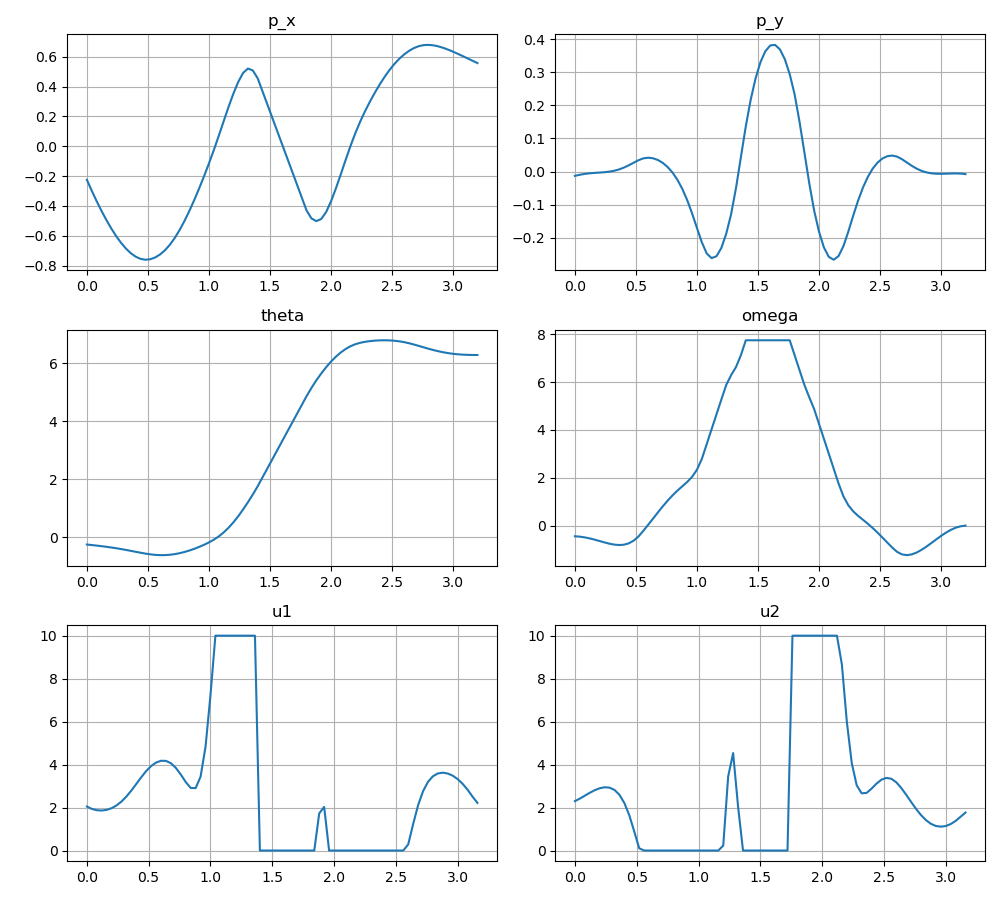

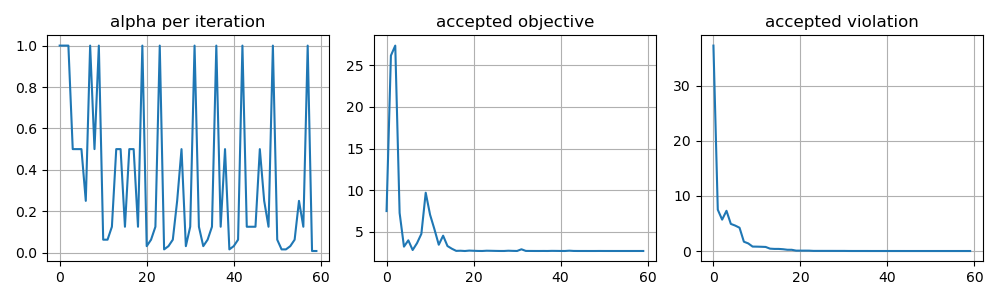

Your browser does not support the video tag.

In [18]:
# ===== Cell 12: Solve SQP and visualize =====

x_opt, hist = sqp_solve(max_outer=60, tol_kkt=1e-4, verbose=True)
extract_and_plot(x_opt, hist, animate=True)  # set animate=True to see the video


In [19]:
# ===== Cell 13: Save plots for report =====
import os

def save_results_to_file(x_opt, hist, filename_traj="trajectory_plot.png", filename_diag="diagnostics_plot.png"):
    """
    Re-plot the data and save to PNG files instead of just showing them.
    """
    z_opt, u_opt = unpack(x_opt, N)
    t = np.arange(N + 1) * DT

    print(f"Saving plots...")

    # --- 1. Save Trajectory Plots ---
    fig1, axs = plt.subplots(3, 2, figsize=(10, 9))
    axs = axs.ravel()

    axs[0].plot(t, z_opt[:, 0])
    axs[0].set_title("p_x"); axs[0].grid(True)

    axs[1].plot(t, z_opt[:, 2])
    axs[1].set_title("p_y"); axs[1].grid(True)

    axs[2].plot(t, z_opt[:, 4])
    axs[2].set_title("theta"); axs[2].grid(True)

    axs[3].plot(t, z_opt[:, 5])
    axs[3].set_title("omega"); axs[3].grid(True)

    axs[4].plot(t[:-1], u_opt[:, 0])
    axs[4].set_title("u1"); axs[4].grid(True)

    axs[5].plot(t[:-1], u_opt[:, 1])
    axs[5].set_title("u2"); axs[5].grid(True)

    plt.tight_layout()
    plt.savefig(filename_traj, dpi=300, bbox_inches='tight')
    plt.close(fig1) # Close figure to prevent double displaying
    print(f"Saved trajectory plot to: {os.path.abspath(filename_traj)}")

    # --- 2. Save Diagnostics Plots ---
    if hist is not None and len(hist.get("alpha", [])) > 0:
        fig2 = plt.figure(figsize=(10, 3))

        plt.subplot(1, 3, 1)
        plt.plot(hist["alpha"])
        plt.title("alpha per iteration")
        plt.grid(True)

        plt.subplot(1, 3, 2)
        plt.plot(hist["f"])
        plt.title("accepted objective")
        plt.grid(True)

        plt.subplot(1, 3, 3)
        plt.plot(hist["c"])
        plt.title("accepted violation")
        plt.grid(True)

        plt.tight_layout()
        plt.savefig(filename_diag, dpi=300, bbox_inches='tight')
        plt.close(fig2)
        print(f"Saved diagnostics plot to: {os.path.abspath(filename_diag)}")

# Run the save function using the variables from the previous cell
save_results_to_file(x_opt, hist)

Saving plots...
Saved trajectory plot to: /scratch/ww2781/reinforcement project1/trajectory_plot.png
Saved diagnostics plot to: /scratch/ww2781/reinforcement project1/diagnostics_plot.png


# Part 2

In [20]:
# ===== Part 2 - Cell 1: build reference for 10s and linearization =====

import numpy as np
import matplotlib.pyplot as plt

# 1) 从 Part1 提取最优状态/控制轨迹（flip 3.2 s）
z_ref_flip, u_ref_flip = unpack(x_opt, N)   # z: (N+1, 6), u: (N, 2)

# 2) 为 MPC 仿真准备 10 秒的参考
T_sim = 10.0
H_sim = int(round(T_sim / DT))   # MPC 仿真步数（控制步数）

# 参考长度：控制长度 H_sim，状态长度 H_sim+1
z_ref = np.zeros((H_sim + 1, DIM_X))
u_ref = np.zeros((H_sim, DIM_U))

for k in range(H_sim):
    if k < N:
        # 前 3.2 s 跟随 flip 轨迹
        z_ref[k] = z_ref_flip[k]
        u_ref[k] = u_ref_flip[k]
    else:
        # flip 结束后改为在最终姿态附近悬停
        z_ref[k] = z_ref_flip[-1]
        z_ref[k, 1] = 0.0  # vx ≈ 0
        z_ref[k, 3] = 0.0  # vy ≈ 0
        z_ref[k, 5] = 0.0  # omega ≈ 0
        u_ref[k] = u_hover

# 最后一个状态点
z_ref[H_sim] = z_ref[-2]  # 与前一时刻保持一致


def linearize_discrete(z, u, dt=DT):
    """
    在 (z, u) 处线性化离散动力学:
        z_{k+1} = z_k + dt * f_cont(z_k, u_k)
    得到 A_d, B_d，使得
        delta z_{k+1} ≈ A_d delta z_k + B_d delta u_k
    """
    px, vx, py, vy, th, om = z
    u1, u2 = u
    s = np.sin(th)
    c = np.cos(th)

    # df/dz
    dfdz = np.zeros((DIM_X, DIM_X))
    dfdz[0, 1] = 1.0        # px_dot 对 vx
    dfdz[2, 3] = 1.0        # py_dot 对 vy
    dfdz[1, 4] = -((u1 + u2) * c) / m    # vx_dot 对 theta
    dfdz[3, 4] = -((u1 + u2) * s) / m    # vy_dot 对 theta
    dfdz[4, 5] = 1.0        # theta_dot 对 omega

    # df/du
    dfdu = np.zeros((DIM_X, DIM_U))
    dfdu[1, 0] = -s / m
    dfdu[1, 1] = -s / m
    dfdu[3, 0] =  c / m
    dfdu[3, 1] =  c / m
    dfdu[5, 0] =  r / I
    dfdu[5, 1] = -r / I

    # 离散系统矩阵
    A_d = np.eye(DIM_X) + dt * dfdz
    B_d = dt * dfdu
    return A_d, B_d


# 沿参考轨迹预计算 A_k, B_k
A_seq = []
B_seq = []
for k in range(H_sim):
    A_k, B_k = linearize_discrete(z_ref[k], u_ref[k])
    A_seq.append(A_k)
    B_seq.append(B_k)

A_seq = np.stack(A_seq, axis=0)  # (H_sim, 6, 6)
B_seq = np.stack(B_seq, axis=0)  # (H_sim, 6, 2)


In [21]:
# ===== Part 2 - Cell 2: LTV-LQR gain sequence =====

# 这里用的 LQR 权重和 Part1 一致的风格：状态偏差大一点权重，控制偏差和变化小一点权重
Q_lqr = np.diag([2.0, 0.1,  2.0, 0.1,  4.0, 0.2])   # state error weight
R_lqr = 0.05 * np.eye(DIM_U)                        # control deviation weight

# 终端权重
P = Q_lqr.copy()
K_seq = [np.zeros((DIM_U, DIM_X)) for _ in range(H_sim)]

for k in reversed(range(H_sim)):
    A = A_seq[k]
    B = B_seq[k]

    # S = R + B^T P B
    S = R_lqr + B.T @ P @ B
    # K = S^{-1} B^T P A
    K = np.linalg.solve(S, B.T @ P @ A)
    K_seq[k] = K

    # Riccati backward update: P_k = Q + A^T P A - A^T P B K
    P = Q_lqr + A.T @ P @ (A - B @ K)

K_seq = np.stack(K_seq, axis=0)  # (H_sim, 2, 6)
print("LQR gains ready, shape:", K_seq.shape)


LQR gains ready, shape: (250, 2, 6)


In [22]:
# ===== Part 2 - Cell 3: MPC controller based on reference + LTV-LQR =====

def mpc_controller(x, t_index):
    """
    MPC 控制器（实际上是沿参考的 LTV-LQR tracking）.

    参数：
      x: 当前状态 (6,)
      t_index: 当前离散时间步 k，由 quadrotor.simulate 传入

    返回：
      u: 控制向量 (2,)
    """
    k = int(t_index)
    if k >= H_sim:
        k = H_sim - 1

    x_ref = z_ref[k]
    u_ref_k = u_ref[k]
    K = K_seq[k]

    # 误差反馈
    e = x - x_ref           # state error
    u = u_ref_k - K @ e     # reference minus feedback

    # 施加推力约束 [0, 10]
    u = np.clip(u, U_MIN, U_MAX)
    return u


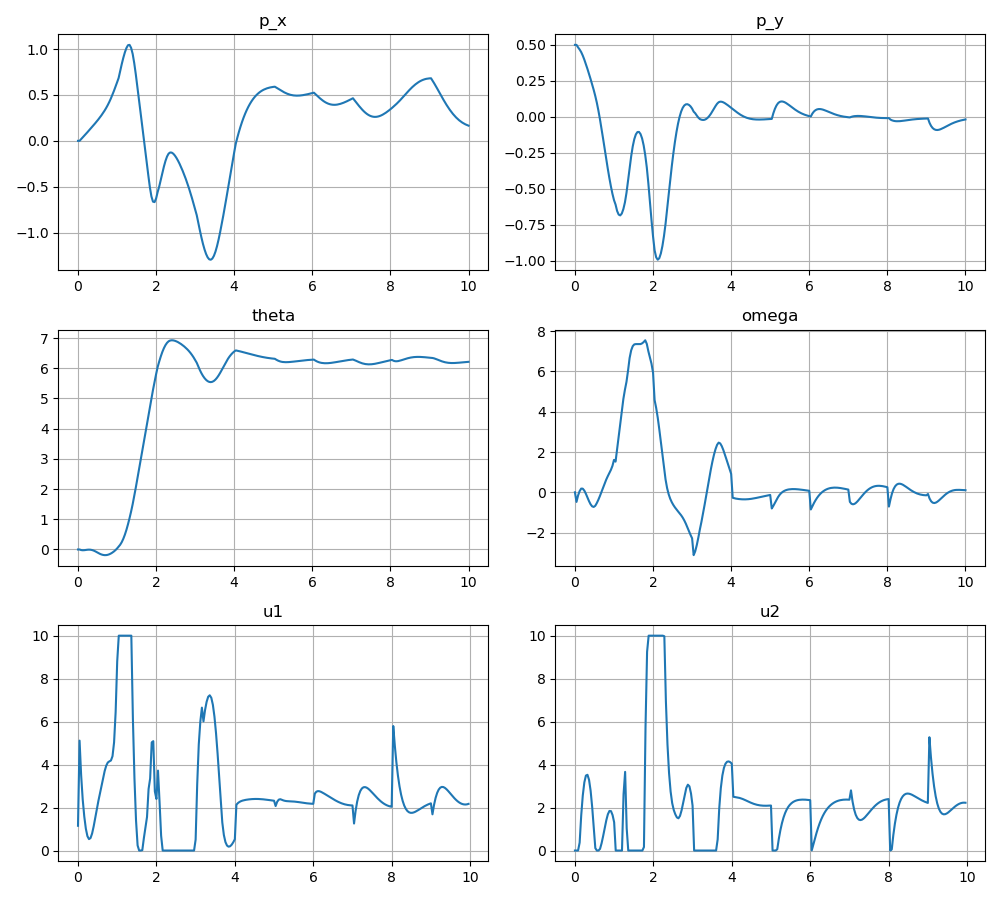

Your browser does not support the video tag.

In [23]:
# ===== Part 2 - Cell 4: simulate MPC with disturbance and visualize =====

# 初始状态，可以和 Part1 一致
x_init_mpc = np.array([0.0, 0.0, 0.5, 0.0, 0.0, 0.0])

horizon_length_sim = H_sim  # 10 s

# 启用随机扰动
t_mpc, state_mpc, u_mpc = quadrotor.simulate(
    x_init_mpc,
    mpc_controller,
    horizon_length_sim,
    disturbance=True
)

# state_mpc: (6, H_sim+1), u_mpc: (2, H_sim)

# ---- 画状态与控制随时间的变化 ----
time_state = np.arange(state_mpc.shape[1]) * DT
time_ctrl = np.arange(u_mpc.shape[1]) * DT

fig, axs = plt.subplots(3, 2, figsize=(10, 9))
axs = axs.ravel()

axs[0].plot(time_state, state_mpc[0, :])
axs[0].set_title("p_x"); axs[0].grid(True)

axs[1].plot(time_state, state_mpc[2, :])
axs[1].set_title("p_y"); axs[1].grid(True)

axs[2].plot(time_state, state_mpc[4, :])
axs[2].set_title("theta"); axs[2].grid(True)

axs[3].plot(time_state, state_mpc[5, :])
axs[3].set_title("omega"); axs[3].grid(True)

axs[4].plot(time_ctrl, u_mpc[0, :])
axs[4].set_title("u1"); axs[4].grid(True)

axs[5].plot(time_ctrl, u_mpc[1, :])
axs[5].set_title("u2"); axs[5].grid(True)

plt.tight_layout()
plt.show()

# ---- 动画显示 ----
quadrotor.animate_robot(state_mpc, u_mpc)


In [24]:
# ===== Part 2 - Final Cell: Save 6-in-1 figure =====

import matplotlib.pyplot as plt

save_path = "./mpc_results_6in1.png"

fig, axs = plt.subplots(3, 2, figsize=(12, 12))
axs = axs.ravel()

# ----- 状态 -----
axs[0].plot(time_state, state_mpc[0, :])
axs[0].set_title("p_x (MPC)")
axs[0].grid(True)

axs[1].plot(time_state, state_mpc[2, :])
axs[1].set_title("p_y (MPC)")
axs[1].grid(True)

axs[2].plot(time_state, state_mpc[4, :])
axs[2].set_title("theta (MPC)")
axs[2].grid(True)

axs[3].plot(time_state, state_mpc[5, :])
axs[3].set_title("omega (MPC)")
axs[3].grid(True)

# ----- 控制 -----
axs[4].plot(time_ctrl, u_mpc[0, :])
axs[4].set_title("u1 (MPC)")
axs[4].grid(True)

axs[5].plot(time_ctrl, u_mpc[1, :])
axs[5].set_title("u2 (MPC)")
axs[5].grid(True)

plt.tight_layout()
plt.savefig(save_path, dpi=200)
plt.close()

print(f"6-in-1 MPC figure saved to: {save_path}")


6-in-1 MPC figure saved to: ./mpc_results_6in1.png


# bonus

In [25]:
# ===== Extra Part - Cell 1: SQP with p_y >= 0 and z0 = 0 =====

def sqp_solve_positive_altitude(max_outer=60, tol_kkt=1e-4, verbose=True):
    """
    SQP solver with:
      - initial state at the origin (z0 = 0),
      - additional state constraint p_y(k) >= 0 for all k.
    """

  
    z0 = np.zeros(DIM_X)   # [px, vx, py, vy, theta, omega] = 0


    z_init, u_init = build_initial_guess(N, z0=z0)
    x = pack(z_init, u_init)

    f_best = np.inf
    c_best = np.inf
    history = {"f": [], "c": [], "alpha": []}

    for it in range(1, max_outer + 1):
        f, g, H = objective_and_derivatives(x)
        G, gvec = build_linearized_dynamics(x)

        # equality constraints: G dx = gvec  (dynamics)
        Aeq = G
        beq = gvec


        z, u = unpack(x, N)
        nvar = x.size
        lb = -np.inf * np.ones(nvar)
        ub =  np.inf * np.ones(nvar)

        # 1) ：U_MIN <= u_k + du_k <= U_MAX
        for k in range(N):
            idx_u = k * (DIM_X + DIM_U) + DIM_X
            lb[idx_u: idx_u + DIM_U] = U_MIN - u[k]
            ub[idx_u: idx_u + DIM_U] = U_MAX - u[k]

        # 2) p_y(k) >= 0
        for k in range(N + 1):
            idx_z = k * (DIM_X + DIM_U)
            py = z[k, 2]  
          
            lb[idx_z + 2] = max(lb[idx_z + 2], -py)

        #  min 0.5 dx^T H dx + g^T dx
        dx = qp_solve_qpsolvers(H, g, Aeq=Aeq, beq=beq, lb=lb, ub=ub, ridge=1e-8)

 
        kkt_norm = max(np.linalg.norm(dx, ord=np.inf), np.linalg.norm(gvec, ord=np.inf))
        c_now = constraint_violation(x)

        if verbose:
            print(f"[SQP+alt] it={it:02d}  f={f:.4e}  |c|={c_now:.2e}  kkt~={kkt_norm:.2e}")

        if kkt_norm < tol_kkt:
            print("SQP with altitude constraint converged.")
            break

        # filter line search
        x_new, alpha, accepted, f_new, c_new, f_best, c_best = filter_line_search(
            x, dx, f_best, c_best, rho=0.5, alpha0=1.0, max_backtrack=20
        )

        history["alpha"].append(alpha)
        history["f"].append(f if f_new is None else f_new)
        history["c"].append(c_now if c_new is None else c_new)

        if not accepted:
            
            x = x + 1e-2 * dx
        else:
            x = x_new

    return x, history


[SQP+alt] it=01  f=2.9995e-31  |c|=3.91e+01  kkt~=7.79e+00
[SQP+alt] it=02  f=1.0211e+01  |c|=4.18e+01  kkt~=1.00e+01
[SQP+alt] it=03  f=7.2688e+00  |c|=2.98e+01  kkt~=1.37e+01
[SQP+alt] it=04  f=9.3351e+00  |c|=1.87e+01  kkt~=2.29e+01
[SQP+alt] it=05  f=5.6113e+00  |c|=1.57e+01  kkt~=1.27e+01
[SQP+alt] it=06  f=8.5802e+00  |c|=9.72e+00  kkt~=2.21e+01
[SQP+alt] it=07  f=4.8239e+00  |c|=9.20e+00  kkt~=1.24e+01
[SQP+alt] it=08  f=4.6437e+00  |c|=7.21e+00  kkt~=1.17e+01
[SQP+alt] it=09  f=4.4879e+00  |c|=6.16e+00  kkt~=1.18e+01
[SQP+alt] it=10  f=4.5896e+00  |c|=6.05e+00  kkt~=1.14e+01
[SQP+alt] it=11  f=4.4094e+00  |c|=5.67e+00  kkt~=1.10e+01
[SQP+alt] it=12  f=4.4218e+00  |c|=5.43e+00  kkt~=1.05e+01
[SQP+alt] it=13  f=4.3221e+00  |c|=4.99e+00  kkt~=1.10e+01
[SQP+alt] it=14  f=3.9301e+00  |c|=4.43e+00  kkt~=5.23e+00
[SQP+alt] it=15  f=4.4627e+00  |c|=1.79e+00  kkt~=1.00e+01
[SQP+alt] it=16  f=4.1388e+00  |c|=1.62e+00  kkt~=7.50e+00
[SQP+alt] it=17  f=4.3036e+00  |c|=6.77e-01  kkt~=1.00e+

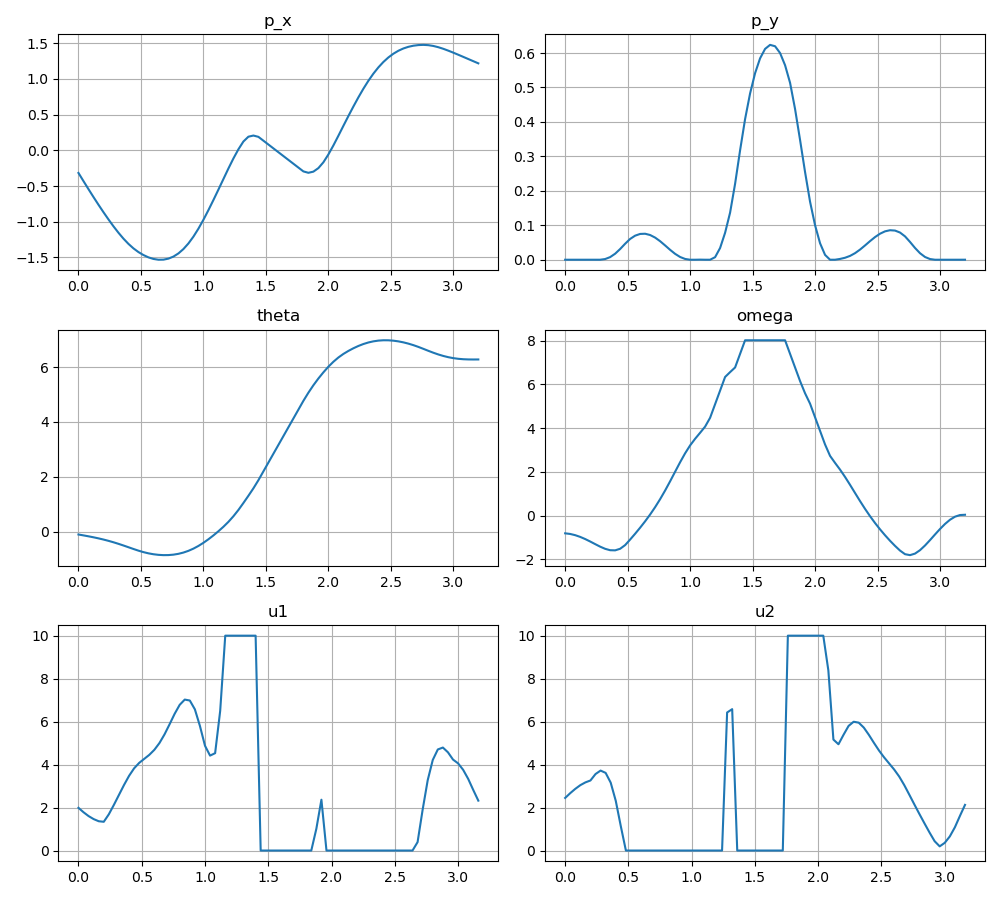

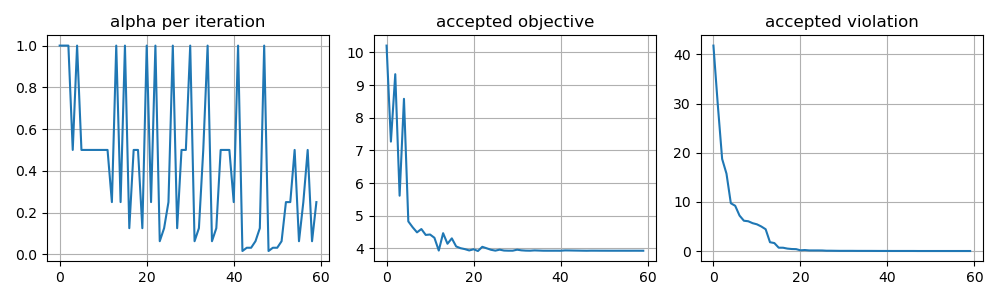

Your browser does not support the video tag.

In [26]:
# ===== Extra Part - Cell 2: Solve and visualize constrained flip =====


x_opt_alt, hist_alt = sqp_solve_positive_altitude(
    max_outer=60,
    tol_kkt=1e-4,
    verbose=True
)


extract_and_plot(x_opt_alt, hist_alt, animate=True)


In [27]:
# ===== Extra Part - Cell 3: Save 6-in-1 and 3-in-1 figures for constrained solution =====

import matplotlib.pyplot as plt
import numpy as np

# 文件名可以按需要改
save_path_6 = "./flip_alt_states_controls_6in1.png"
save_path_3 = "./flip_alt_sqp_diagnostics_3in1.png"


z_alt, u_alt = unpack(x_opt_alt, N)      # z_alt: (N+1, 6), u_alt: (N, 2)
t_alt   = np.arange(N + 1) * DT          
t_u_alt = np.arange(N) * DT              


fig, axs = plt.subplots(3, 2, figsize=(12, 12))
axs = axs.ravel()

axs[0].plot(t_alt, z_alt[:, 0])
axs[0].set_title("p_x")
axs[0].grid(True)

axs[1].plot(t_alt, z_alt[:, 2])
axs[1].set_title("p_y")
axs[1].grid(True)

axs[2].plot(t_alt, z_alt[:, 4])
axs[2].set_title("theta")
axs[2].grid(True)

axs[3].plot(t_alt, z_alt[:, 5])
axs[3].set_title("omega")
axs[3].grid(True)

axs[4].plot(t_u_alt, u_alt[:, 0])
axs[4].set_title("u1")
axs[4].grid(True)

axs[5].plot(t_u_alt, u_alt[:, 1])
axs[5].set_title("u2")
axs[5].grid(True)

plt.tight_layout()
plt.savefig(save_path_6, dpi=200)
plt.close(fig)

print(f"Saved 6-in-1 states/controls figure to: {save_path_6}")


if (hist_alt is not None 
    and isinstance(hist_alt, dict) 
    and len(hist_alt.get("alpha", [])) > 0):

    iters = np.arange(1, len(hist_alt["alpha"]) + 1)

    fig2, axs2 = plt.subplots(1, 3, figsize=(12, 4))

    # alpha
    axs2[0].plot(iters, hist_alt["alpha"])
    axs2[0].set_title("step size (alpha)")
    axs2[0].set_xlabel("iteration")
    axs2[0].grid(True)

    # objective
    axs2[1].plot(iters, hist_alt["f"])
    axs2[1].set_title("accepted objective")
    axs2[1].set_xlabel("iteration")
    axs2[1].grid(True)

    # constraint violation
    axs2[2].plot(iters, hist_alt["c"])
    axs2[2].set_title("accepted violation")
    axs2[2].set_xlabel("iteration")
    axs2[2].grid(True)

    plt.tight_layout()
    plt.savefig(save_path_3, dpi=200)
    plt.close(fig2)

    print(f"Saved 3-in-1 SQP diagnostics figure to: {save_path_3}")
else:
    print("No diagnostics saved: hist_alt is empty or not available.")


Saved 6-in-1 states/controls figure to: ./flip_alt_states_controls_6in1.png
Saved 3-in-1 SQP diagnostics figure to: ./flip_alt_sqp_diagnostics_3in1.png
